In [268]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.ndimage import gaussian_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

# Tilt and beads: Memory effect

**Moving completely to thin lens modeling**

* Ensuring proper sampling, wavefield size, and boundary conditions
* *Simulate and save phase mask with proper sizes*
    * Try different densities of structures
    * Compare outputs from different samplings
* Ensure proper simulation w.r.t. medium RIs
* Compare BPM vs Thin sample modeling
    * *Make videos for propagation distances*
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * Speckle size increases with distance?
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

((2000, 2000), dtype('float64'))

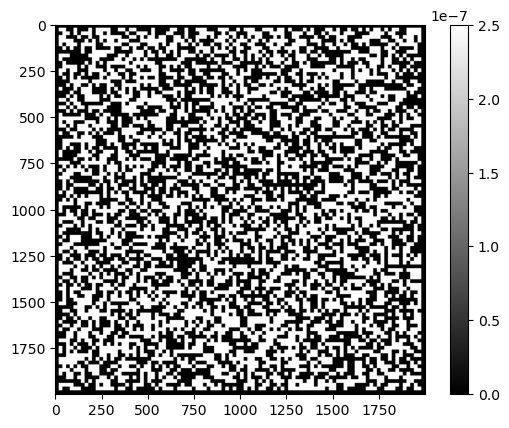

In [2]:
# create phase mask: 
# 2d matrix height map for phase delay
# 2d matrix for different RI?

# Grid and propagation parameters setup
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.5)

plt.imshow(h_map, cmap='gray')
plt.colorbar()

h_map.shape, h_map.dtype

In [3]:
print(np.unique(h_map))

## given h_map, find delay of entire plane corresponding to the largest height
## max h_map = t
## delay at largest height = t*RI(x,y)
## delay where height = 0, t*1
## remaining regions: h(x,y)*RI(x,y) + (1-h(x,y)*1)

t = h_map.max()
RI = np.ones_like(h_map)*1.46
opd = h_map*RI + (t-h_map)*n_0

[0.0e+00 2.5e-07]


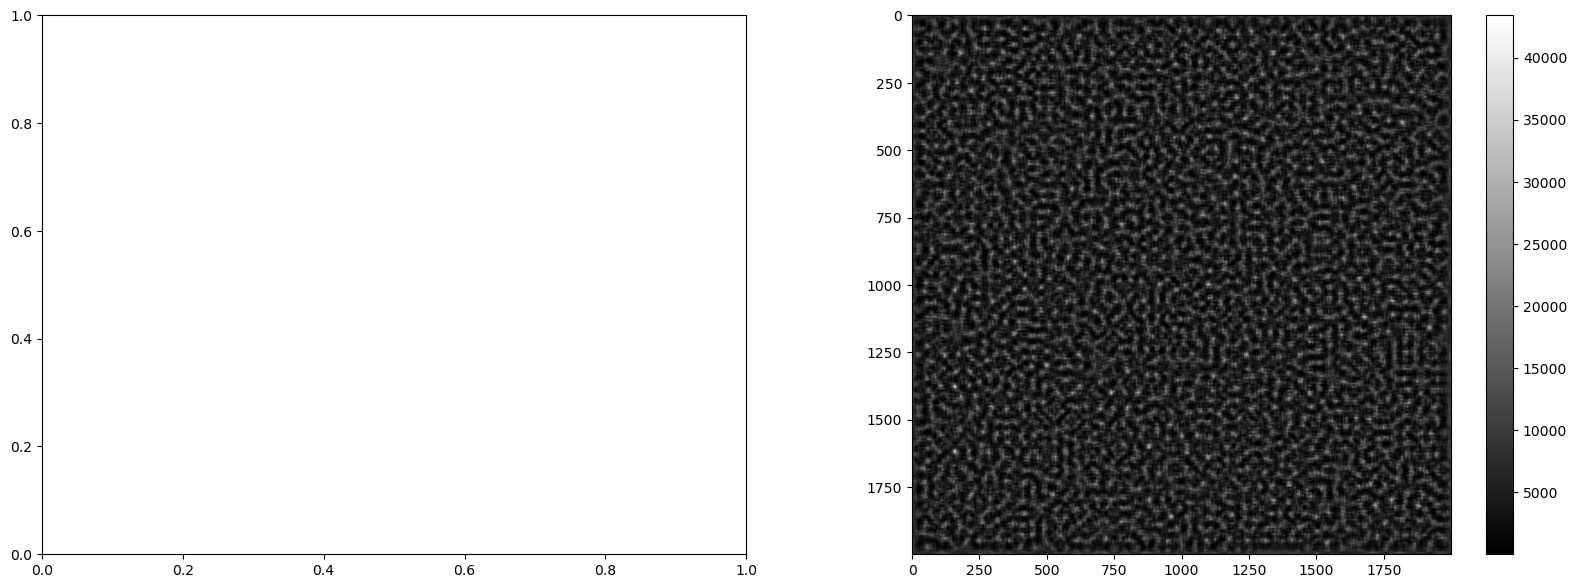

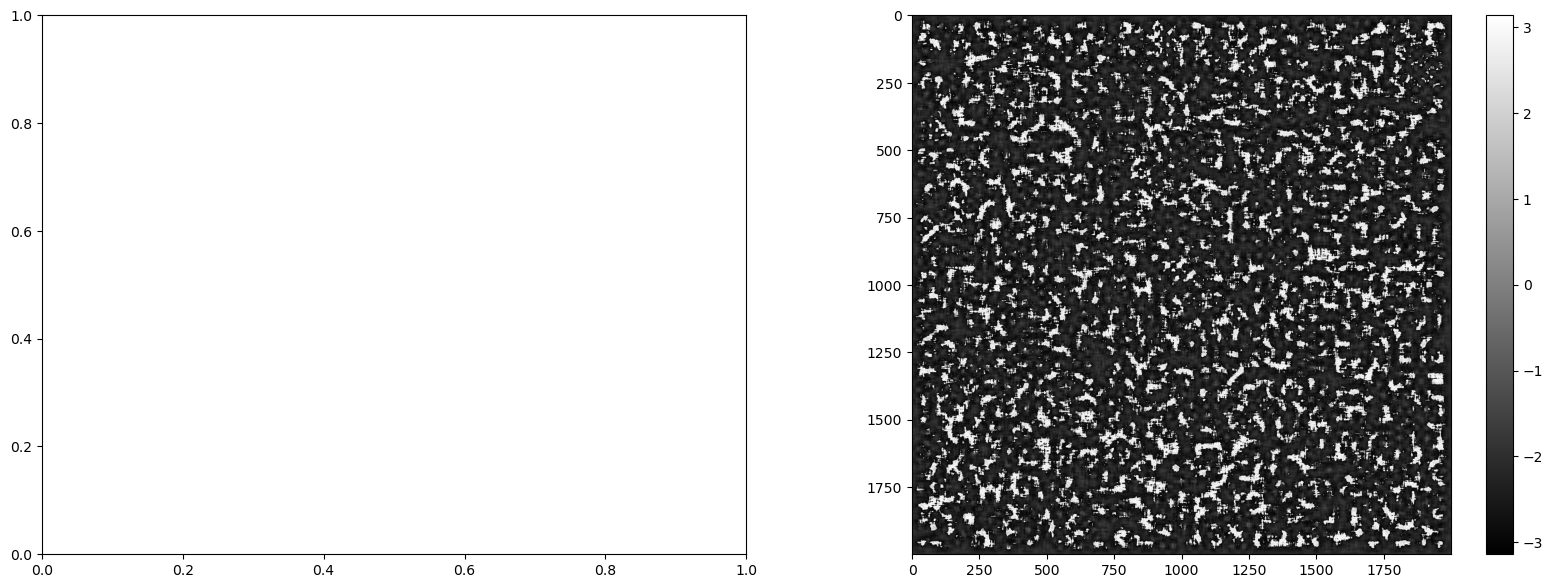

In [4]:
field = np.zeros([nx, nx])
field[:, :] = 80

phase_delay = np.exp(-1j*(2*np.pi/wl)*opd)
output_field_2 = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], 500e-6, padding=1024)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

# fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
# plt.colorbar(cm0, ax=axs[0])

# cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
# plt.colorbar(cm1, ax=axs[1])

# plt.show()

# BEAD Memory Effect

Coordiante system with size: 
 
              X = [0, 1.50e-04], Res_X = 5e-07
              Y = [0, 1.50e-04], Res_Y = 5e-07
              Z = [0, 1.25e-05], Res_Z = 5e-08
              Immersion RI: 1.512
      


qt.qpa.xcb: QXcbConnection: XCB error: 146 (Unknown), sequence: 7255, resource id: 0, major code: 139 (Unknown), minor code: 20
qt.qpa.xcb: QXcbConnection: XCB error: 146 (Unknown), sequence: 7260, resource id: 1232, major code: 139 (Unknown), minor code: 20
qt.qpa.xcb: QXcbConnection: XCB error: 146 (Unknown), sequence: 7266, resource id: 1232, major code: 139 (Unknown), minor code: 20


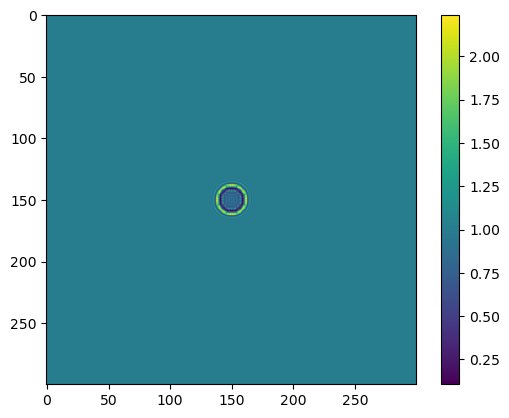

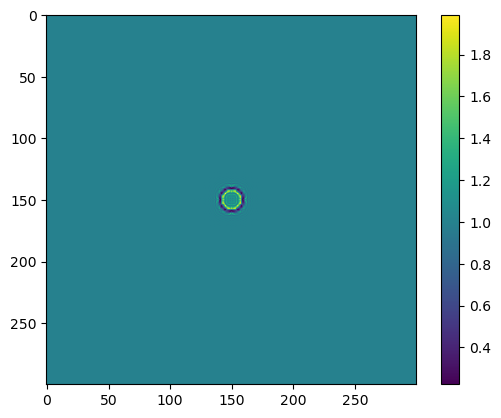

In [243]:
# bead wfs simulation

field = np.ones([300, 300])*1

# object
geom2 = geometry.Geometry([300, 300, 250], [dx, dx, 50e-9], 1.512)
geom2.add_sphere(center=(150*dx, 150*dx, 125*50e-9), radius=5e-6, RI=1.46)
visualization.visualize_grid_vol(geom2.get_grid()[:, :, ::10], n_background=geom2.n_0, factor=2)

output_bead_field = propagator.propagate_beam_2(field, geom2.get_grid(), geom2.n_0, wl, [dx, dx, 50e-9])

plt.imshow(np.abs(output_bead_field)**2)
plt.colorbar()
plt.show()

output_bead_field_focus = propagator.propagate(output_bead_field, wl, [dx, dx, 50e-9], -1*125*50e-9)

plt.imshow(np.abs(output_bead_field_focus)**2)
plt.colorbar()
plt.show()

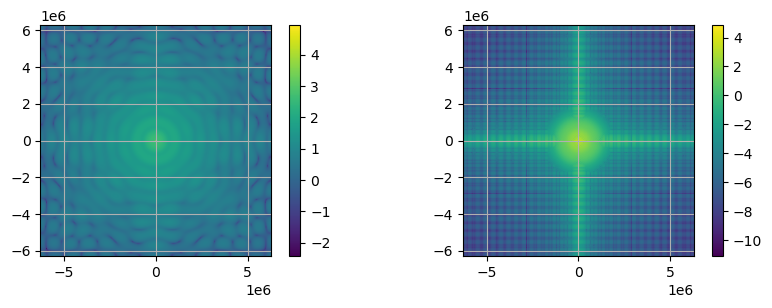

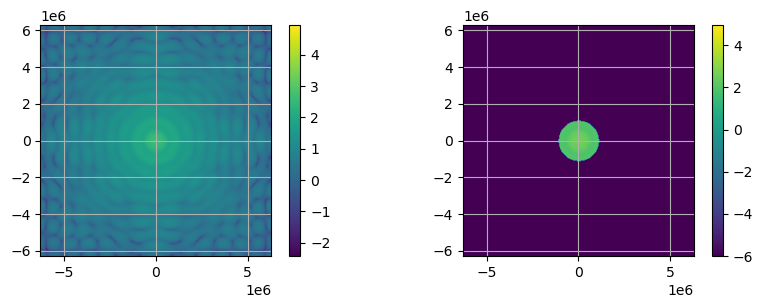

1.0950510458516882


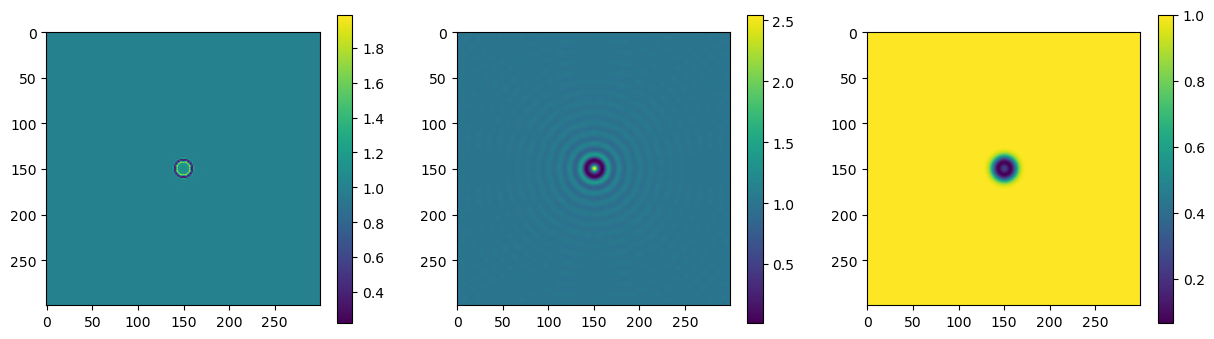

In [277]:
bead_fft_obj = np.fft.fft2(output_bead_field_focus)

apod = np.outer(tukey(bead_fft_obj.shape[0], 0.2), tukey(bead_fft_obj.shape[0], 0.2))

bead_fft_obj_lpf = np.fft.fft2(apod*gaussian_filter(output_bead_field_focus, 5))
beads_fft_freq = np.meshgrid(np.pi*2*np.fft.fftfreq(bead_fft_obj.shape[0], dx), np.pi*2*np.fft.fftfreq(bead_fft_obj.shape[0], dx), indexing='ij')

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
# plt.imshow(apod, extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
cm0 = axs[0].imshow(np.fft.fftshift(np.log10(np.abs(bead_fft_obj))), extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
plt.colorbar(cm0, ax=axs[0])
axs[0].grid()

cm1 = axs[1].imshow(np.fft.fftshift(np.log10(np.abs(bead_fft_obj_lpf))), extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
plt.colorbar(cm1, ax=axs[1])
axs[1].grid()
plt.show()


mag = 10
NA = 0.9

freq_cut_off = np.pi/(mag*0.61*wl/(NA*1.512))


fig, axs = plt.subplots(1, 2, figsize=(10, 3))

bead_fft_img = np.where(beads_fft_freq[0]**2 + beads_fft_freq[1]**2 < freq_cut_off**2, bead_fft_obj, 1e-6)
# bead_fft_img = np.fft.fftshift(apod)*bead_fft_obj

# plt.imshow(apod, extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
cm0 = axs[0].imshow(np.fft.fftshift(np.log10(np.abs(bead_fft_obj))), extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
plt.colorbar(cm0, ax=axs[0])
axs[0].grid()

cm1 = axs[1].imshow(np.fft.fftshift(np.log10(np.abs(bead_fft_img))), extent=[-1*np.pi/(dx), np.pi/(dx), -1*np.pi/(dx), np.pi/(dx)])
plt.colorbar(cm1, ax=axs[1])
axs[1].grid()
plt.show()

print(freq_cut_off/1e6)

bead_lpf = np.fft.ifft2(bead_fft_img)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

cm0 = axs[0].imshow(np.abs(output_bead_field_focus)**2)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(bead_lpf)**2)
plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.abs(gaussian_filter(output_bead_field_focus, 5))**2)
plt.colorbar(cm2, ax=axs[2])

plt.show()

In [64]:
# beads_fft_freq[0].shape, 2*np.pi*np.fft.fftfreq(bead_fft_obj.shape[0], dx).min()/1e6, -1*np.pi/(dx)/1e6

((300, 300), -6.283185307179586, -6.283185307179587)

In [248]:
bead_interp = RegularGridInterpolator((np.arange(100) * 500e-9, np.arange(100) * 500e-9), bead_lpf[100:200, 100:200], 
                                      bounds_error=False, fill_value=None)

xx = np.arange(1000) * 50e-9
yy = np.arange(1000) * 50e-9
X, Y = np.meshgrid(xx, yy, indexing='ij')

bead_lpf_mag = bead_interp((X, Y))

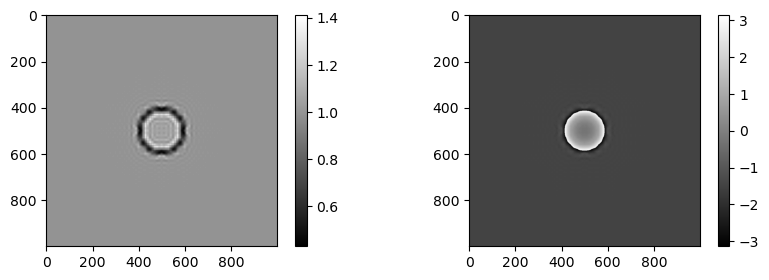

In [249]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

cm0 = axs[0].imshow(np.abs(bead_lpf_mag), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(bead_lpf_mag), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

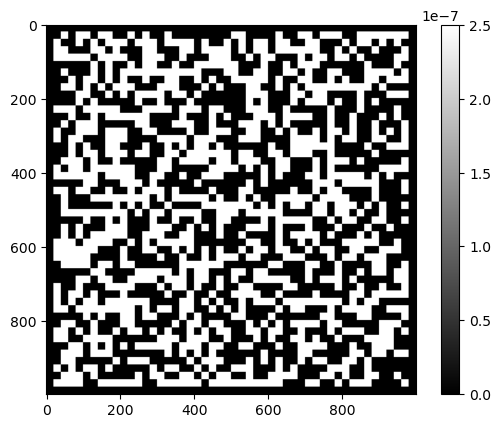

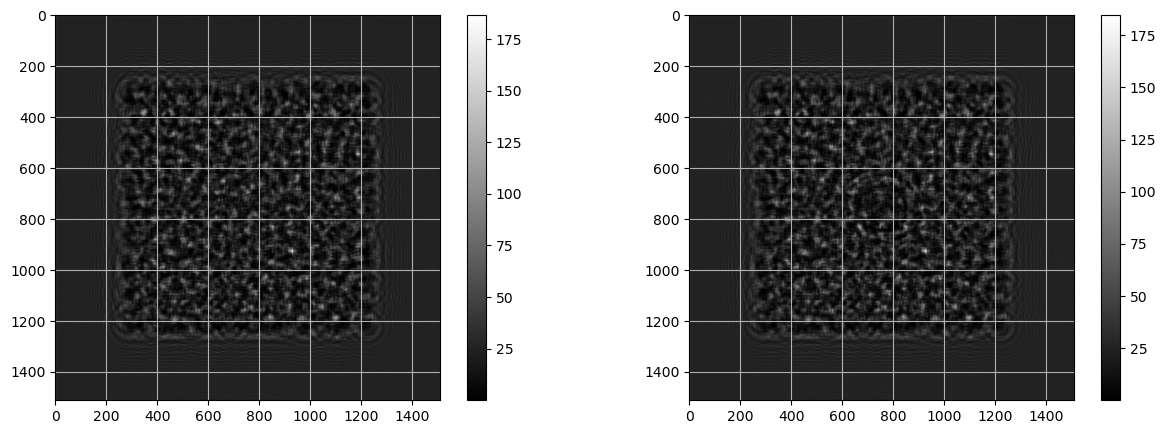

In [265]:
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 1000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.5)

plt.imshow(h_map, cmap='gray')
plt.colorbar()

t = h_map.max()
RI = np.ones_like(h_map)*1.46
opd = h_map*RI + (t-h_map)*n_0

field = np.zeros([nx, nx])
field[:, :] = 5

xx = np.arange(1512) * 50e-9
yy = np.arange(1512) * 50e-9
X, Y = np.meshgrid(xx, yy, indexing='ij')

phase_delay = np.exp(-1j*(2*np.pi/wl)*opd)

ref = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), wl/1.49, [dx, dx], 1.e-3, padding=None)
bead = propagator.propagate(np.pad(field*phase_delay*bead_lpf_mag, 256, 'edge'), wl/1.49, [dx, dx], 1.e-3, padding=None)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.abs(ref)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])
axs[0].grid()
cm1 = axs[1].imshow(np.abs(bead)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])
axs[1].grid()
plt.show()

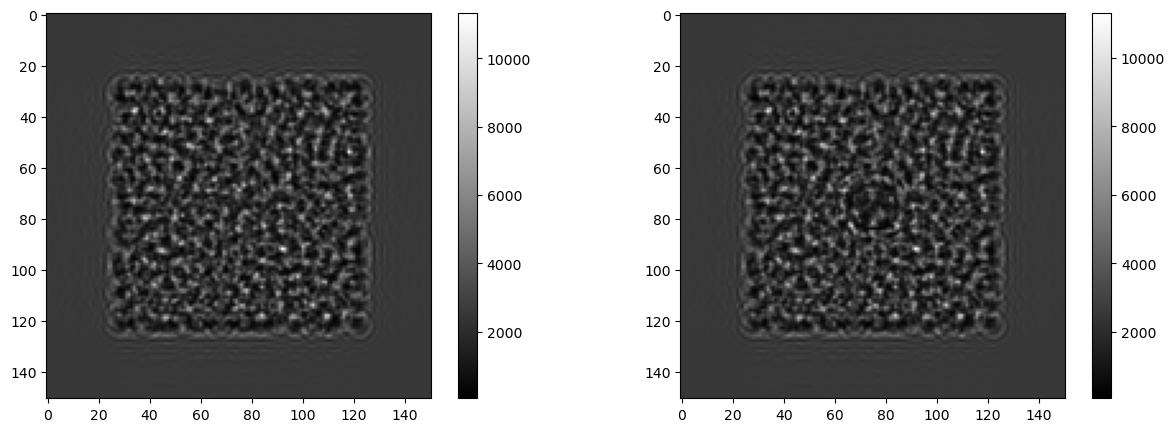

11311.213263908105 52.777148194628964


In [266]:
ref = np.abs(ref)**2
bead = np.abs(bead)**2

ref = convolve2d(ref, np.ones([10, 10]), mode='valid')[::10, ::10]
bead = convolve2d(bead, np.ones([10, 10]), mode='valid')[::10, ::10]

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(ref, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(bead, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

print(ref.max(), ref.min())

In [264]:
# ref = np.array(ref, dtype=np.uint16) + 20
# bead = np.array(bead, dtype=np.uint16) + 20

# tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_3_mm_int_aerial_ref.tiff', ref)
# tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_3_mm_int_aerial_bead.tiff', bead)

9629 62
9736 57


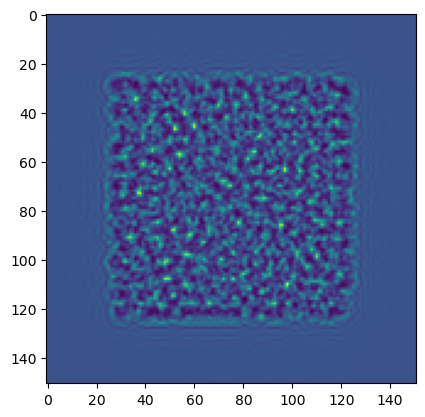

In [198]:
print(ref.max(), ref.min())
print(bead.max(), bead.min())
bead.shape

plt.imshow(ref)

# TILT Memory Effect

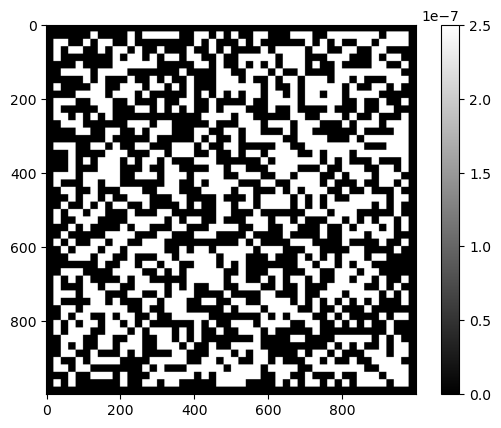

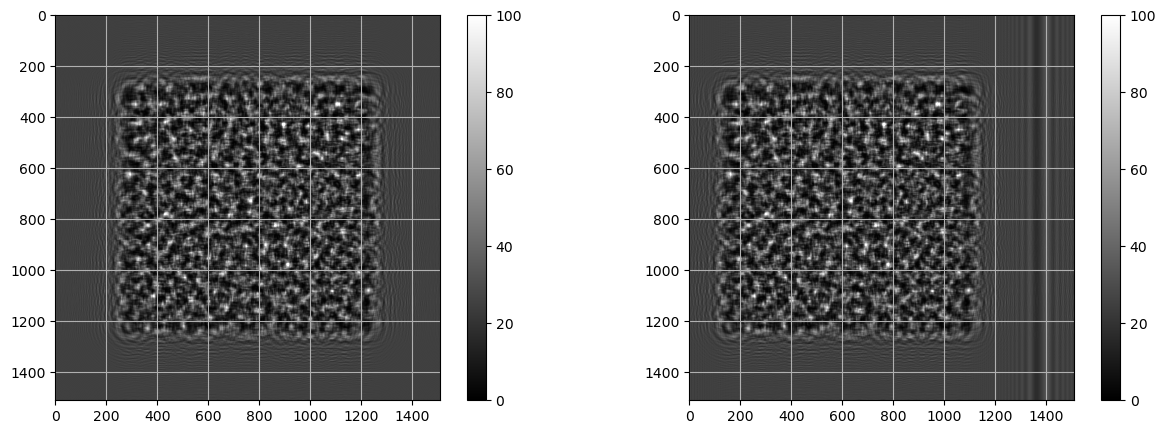

In [ ]:
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 1000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.5)

plt.imshow(h_map, cmap='gray')
plt.colorbar()

t = h_map.max()
RI = np.ones_like(h_map)*1.46
opd = h_map*RI + (t-h_map)*n_0

field = np.zeros([nx, nx])
field[:, :] = 5

xx = np.arange(1512) * 50e-9
yy = np.arange(1512) * 50e-9
X, Y = np.meshgrid(xx, yy, indexing='ij')

phase_delay = np.exp(-1j*(2*np.pi/wl)*opd)
tilt_wave = np.exp(-1j*(2*np.pi/wl)*(np.sin(75*np.pi/180)*Y))
# tilt_wave_2 = np.exp(1j*(2*np.pi/wl)*(np.sin(75*np.pi/180)*Y))


ref = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), wl/1.49, [dx, dx], 1.e-3, padding=None)
bead = propagator.propagate(np.pad(field*phase_delay, 256, 'edge')*tilt_wave, wl/1.49, [dx, dx], 1.e-3, padding=None)
# bead = bead*tilt_wave_2

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.abs(ref)**2, cmap='gray', vmin=0, vmax=100)
plt.colorbar(cm0, ax=axs[0])
axs[0].grid()
cm1 = axs[1].imshow(np.abs(bead)**2, cmap='gray', vmin=0, vmax=100)
plt.colorbar(cm1, ax=axs[1])
axs[1].grid()
plt.show()

ref = np.abs(ref)**2
bead = np.abs(bead)**2

# ref = convolve2d(ref, np.ones([10, 10]), mode='valid')[::10, ::10]
# bead = convolve2d(bead, np.ones([10, 10]), mode='valid')[::10, ::10]

ref = np.array(ref, dtype=np.uint16)
bead = np.array(bead, dtype=np.uint16)

# tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_3_mm_int_aerial_ref.tiff', ref)
# tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_3_mm_int_aerial_tilt.tiff', bead)